In [2]:
import pennylane as qml

In [3]:
dataset = qml.data.load("qspin", sysname="Heisenberg", periodicity="open", lattice="chain", layout="1x4")[0]

In [4]:
print(dataset.spin_system)

{'name': 'Heisenberg XXZ', 'parameter': 'Z coupling constant, J_z', 'ham_eq': 'J_{xy}\\sum_{\\langle i,j\\rangle}(\\sigma_i^x\\sigma_j^x+\\sigma_i^y\\sigma_j^y) + J_z\\sum_{\\langle i,j\\rangle} \\sigma_i^z \\sigma_j^z', 'order_params': 'The order parameter is the magnetization in the Z direction, defined by \\langle M_z \rangle =\\langle |\\sum_i \\sigma_i^z|\rangle'}


In [5]:
hamiltonian = dataset.hamiltonians[0]

In [6]:
from scipy.stats import unitary_group

n_qubits = 4
n_random_states = 100

# Generate several random unitaries
random_unitaries = unitary_group.rvs(2**n_qubits, n_random_states)
# Take the first column of each unitary as a random state
random_states = [random_unitary[:, 0] for random_unitary in random_unitaries]

(<Figure size 500x500 with 1 Axes>, <Axes: >)

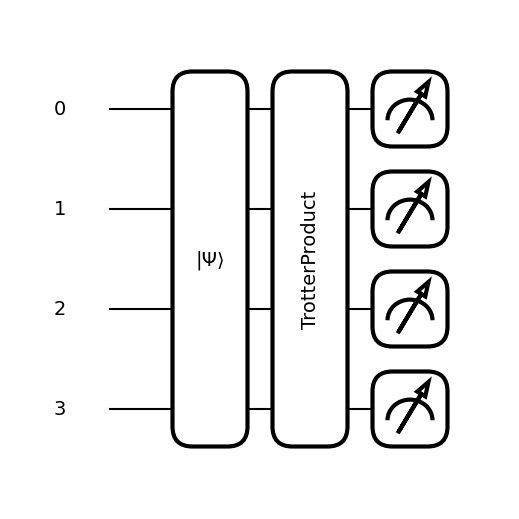

In [7]:
dev = qml.device("default.qubit")

@qml.qnode(dev)
def target_circuit(input_state):
    # prepare training state
    qml.StatePrep(input_state, wires=range(n_qubits))

    # evolve the Hamiltonian for time=2 in n=1 steps with the order 1 formula
    qml.TrotterProduct(hamiltonian, time=2, n=1, order=1)
    return qml.classical_shadow(wires=range(n_qubits))


qml.draw_mpl(target_circuit)(random_states[0])

In [8]:
n_measurements = 10000

shadows = []
for random_state in random_states:
    bits, recipes = target_circuit(random_state, shots=n_measurements)
    shadow = qml.ClassicalShadow(bits, recipes)
    shadows.append(shadow)

(<Figure size 1100x500 with 1 Axes>, <Axes: >)

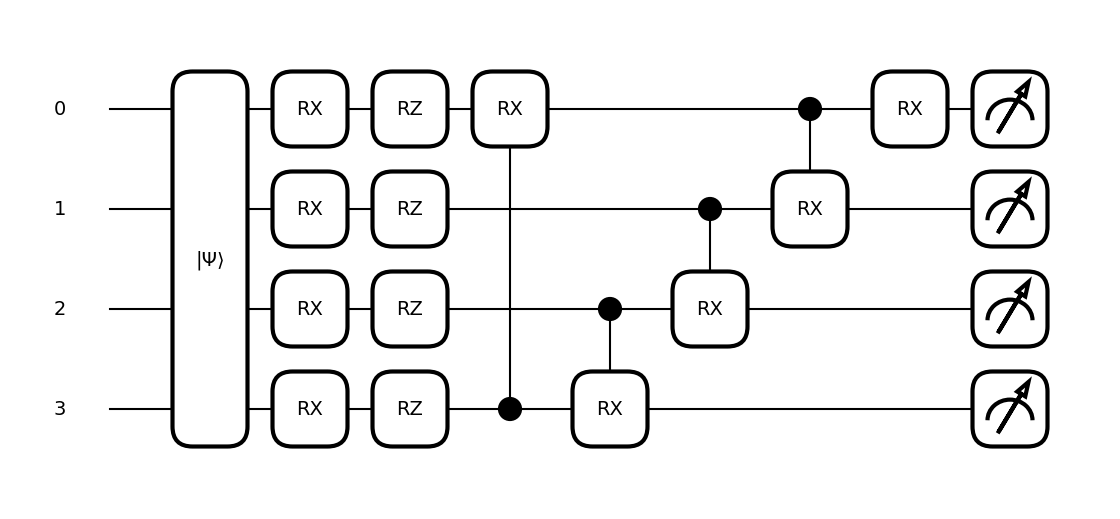

In [20]:
from qml_essentials.model import Model
import pennylane.numpy as np
from typing import Union

model = Model(
    n_qubits=n_qubits,
    n_layers=1,
    circuit_type="Circuit_19",
    data_reupload=False,
    encoding="RX",
)


def _circuit(
        *args,
        inputs: np.ndarray,
        **kwargs,
    ) -> Union[float, np.ndarray]:
        """
        Creates a circuit with noise.

        Args:
            params (np.ndarray): weight vector of shape
                [n_layers, n_qubits*n_params_per_layer]
            inputs (np.ndarray): input vector of size 1
        Returns:
            Union[float, np.ndarray]: Expectation value of PauliZ(0)
                of the circuit if state_vector is False and expval is True,
                otherwise the density matrix of all qubits.
        """
        qml.StatePrep(inputs.flatten(), wires=range(n_qubits))
        return model._circuit(*args, inputs=inputs, **kwargs)

model.circuit = qml.QNode(
    _circuit,
    qml.device(
        "default.qubit",
        shots=model.shots,
        wires=model.n_qubits,
    ),
    interface="autograd" if model.shots is not None else "auto",
    diff_method="parameter-shift" if model.shots is not None else "best",
)
model.circuit_mixed = qml.QNode(
            _circuit,
            qml.device("default.mixed", shots=model.shots, wires=model.n_qubits),
        )

model.draw(inputs=random_states[0], figure="mpl")

In [21]:
model(inputs=random_states[0])

TypeError: _circuit() missing 1 required keyword-only argument: 'inputs'

In [14]:
def cost(params):
    cost = 0.0
    for idx, random_state in enumerate(random_states):
        # obtain the density matrices for each qubit
        observable_mats = model(params=params, inputs=random_state)
        # convert to a PauliSentence
        observable_pauli = [
            qml.pauli_decompose(observable_mat, wire_order=[qubit])
            for qubit, observable_mat in enumerate(observable_mats)
        ]
        # estimate the overlap for each qubit
        cost = cost + qml.math.sum(shadows[idx].expval(observable_pauli))
    cost = 1 - cost / n_qubits / n_random_states
    return cost

In [15]:
optimizer = qml.GradientDescentOptimizer(stepsize=5)
steps = 50

costs = [None]*(steps+1)
params_list = [None]*(steps+1)

params_list[0]=model.params
for i in range(steps):
    params_list[i + 1], costs[i] = optimizer.step_and_cost(cost, params_list[i])

costs[-1] = cost(params_list[-1])

print("Initial cost:", costs[0])
print("Final cost:", costs[-1])

TypeError: _circuit() missing 1 required keyword-only argument: 'inputs'